In [1]:
from src.interfaces.reaction_sequence_builder import ReactionSequenceBuilder


from src import FragmentManager, MoleculeRenderer, ChemistryOperations, ProgressTracker
 

In [2]:


def draw_mol(mol, title="", highlight_atoms=None, highlight_bonds=None, display_props=None):
    mr = MoleculeRenderer()
    display(mr.render_2d(mol, title, highlight_atoms, highlight_bonds, display_props))

In [6]:

# Create fragment manager and load from library
fragment_manager = FragmentManager()
 
print("⚠ Library file not found, creating test fragments...")

# Create test fragments if library doesn't exist
from src.io.format_converters import FormatConverters

# Test fragments data
methyl_acrylate_json = {
    "name": "Methyl_acrylate",
    "smiles": "C=CC(OC)=O",
    "connection_atoms": [0, 2],
    "replacement_groups": ["=1", "OC"],
    "num_atoms": 6
}

ethylenediamine_json = {
    "name": "Ethylenediamine",
    "smiles": "NCCN",
    "connection_atoms": [0, 3],
    "replacement_groups": ["H", "H"],
    "num_atoms": 4
}

# Convert and add to manager
methyl_acrylate_mol = FormatConverters.json_to_metadata_mol(methyl_acrylate_json)
ethylenediamine_mol = FormatConverters.json_to_metadata_mol(ethylenediamine_json)

fragment_manager.add_fragment(
    fragment=methyl_acrylate_mol,
    name="Methyl_acrylate",
    connection_atoms=[0, 2],
    replacement_groups=["=1", "OC"]
)

fragment_manager.add_fragment(
    fragment=ethylenediamine_mol,
    name="Ethylenediamine",
    connection_atoms=[0, 3],
    replacement_groups=["H", "H"]
)


⚠ Library file not found, creating test fragments...


[21:15:12] DEPRECATION WARNING: please use GetValence(which=)
[21:15:12] DEPRECATION WARNING: please use GetValence(which=)
[21:15:12] DEPRECATION WARNING: please use GetValence(which=)
[21:15:12] DEPRECATION WARNING: please use GetValence(which=)
[21:15:12] DEPRECATION WARNING: please use GetValence(which=)
[21:15:12] DEPRECATION WARNING: please use GetValence(which=)
[21:15:12] DEPRECATION WARNING: please use GetValence(which=)
[21:15:12] DEPRECATION WARNING: please use GetValence(which=)
[21:15:12] DEPRECATION WARNING: please use GetValence(which=)
[21:15:12] DEPRECATION WARNING: please use GetValence(which=)


'Ethylenediamine'

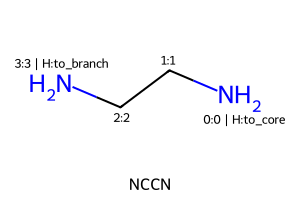

In [7]:
ethylenediamine_mol=fragment_manager.get_fragment('Ethylenediamine')['molecule']
methyl_acrylate_mol=fragment_manager.get_fragment('Methyl_acrylate')['molecule']


 
draw_mol(ethylenediamine_mol, display_props=['original_index', "replacement_group", "connection_type"])

In [8]:


molecule_renderer = MoleculeRenderer()
chemistry_operations = ChemistryOperations()
sequence_builder = ReactionSequenceBuilder(molecule_renderer, fragment_manager, chemistry_operations)
progress_tracker = ProgressTracker()
reaction_steps=['Methyl_acrylate']


  # Initialize progress tracker
progress_tracker.start_construction(len(reaction_steps))
reaction_sequence, branch_points=sequence_builder.build_reaction_sequence(ethylenediamine_mol,reaction_steps, progress_tracker)


Детальный анализ структуры
Атом соединения: N(3)
Replacement group: H

Соседи атома соединения:
   Сосед 0: C(2) → соседи: ['C(1)']

Поиск соответствующей ветки:

=== ВЫПОЛНЕНИЕ REDUCE ===
Атомы для удаления: []
Связь для разрыва: None
Добавлено 1 явных водородов к атому 3
Reduce завершен успешно

Детальный анализ структуры
Атом соединения: C(0)
Replacement group: =1

Структура replacement_group:
   Атом 0: C → соседи: []

Соседи атома соединения:
   Сосед 0: C(1) → соседи: ['C(2)']
Связь для разрыва: 0
   Для спецификации связи - разрыв связи 0

=== ВЫПОЛНЕНИЕ REDUCE ===
Атомы для удаления: []
Связь для разрыва: 0
Уменьшена кратность связи: 0
Reduce завершен успешно

=== Выполнение connect ===
Базовая молекула: атом 3
Дополнительная молекула: атом 0
После объединения: базовый атом 3, дополнительный атом 4
Connect завершен успешно


In [9]:
reaction_sequence

[{'generation': 0,
  'branch': -1,
  'step': 0,
  'base_mol': <rdkit.Chem.rdchem.Mol at 0x180ee516dc0>,
  'additional_mol': <rdkit.Chem.rdchem.Mol at 0x180ee515690>,
  'result_mol': <rdkit.Chem.rdchem.Mol at 0x180ee5e09e0>,
  'connection_points': {'base': 3, 'additional': 0}}]

In [10]:
branch_points

[3]